In [297]:
# 라이브러리 설치
# !pip install torch torchvision torchaudio

In [298]:
# 라이브러리 로드
import torch
import torch.nn as nn
import torch.optim as optim

In [299]:
# 데이터셋 생성
# 독립, 종송 -> 파이토치에서는 독립, 종속 변수의 데이터의 타입은 Tensor로 구성
# 독립 변수 -> 2차원 데이터
# 종속 변수 -> 2차원 데이터
X = torch.tensor( [[1.0], [2.0], [3.0], [4.0]] )
# 종속 변수는 독립변수 데이터에서 2를 곱하고 1을 더해준 값으로 생성
Y = torch.tensor( [[3.0], [5.0], [7.0], [9.0]] )


In [300]:
type(X)

torch.Tensor

In [301]:
# 선형 회귀
class LinearReg(nn.Module):
    # 생성자 함수
    def __init__(self):
        # self : 클래스가 생성된 메모리의 주소
        # super() : 부모 클래스(nn.Module)를 의미 -> 상속
        super(LinearReg, self).__init__()   # 부모 클래스의 생성자 함수를 실행
        # Linear()에서 첫 번째 인자는 입력 데이터의 크기
        # 두 번째 인자는 출력의 크기
        self.linear = nn.Linear(1, 1)
  
    def forward(self, x):
        return self.linear(x)

In [302]:
# 모델을 생성 -> 회귀 모델
# LinearReg 라는 클래스에서 생성자 함수에 매개변수가 self를 제외하고 존재하지 않기 때문에 클래스 생성 시 인자값을 넣지 않는다.
model = LinearReg()

In [303]:
# 손실 함수
criterion = nn.MSELoss()
# 가중치의 갱신 (경사 하강법) lr은 가중치의 변환 시 변환 비율
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [304]:
# 500번 반복 실행하면서 Loss를 확인
for epoch in range(500):
    # 순전파
    Y_pred = model(X)
    # 손실함수
    loss = criterion(Y_pred, Y)
    # 역전파
    optimizer.zero_grad()   # 기울기 초기화
    loss.backward()     # 기울기 계산
    optimizer.step()    # 파라미터를 업데이트

    # 50회 마다 loss의 값을 출력
    if (epoch + 1) % 50 == 0:
        print(f'Epoch : [{epoch}, 500], Loss : {round(loss.item(), 4)}')

Epoch : [49, 500], Loss : 0.009
Epoch : [99, 500], Loss : 0.0067
Epoch : [149, 500], Loss : 0.0049
Epoch : [199, 500], Loss : 0.0037
Epoch : [249, 500], Loss : 0.0027
Epoch : [299, 500], Loss : 0.002
Epoch : [349, 500], Loss : 0.0015
Epoch : [399, 500], Loss : 0.0011
Epoch : [449, 500], Loss : 0.0008
Epoch : [499, 500], Loss : 0.0006


In [305]:
# 예측 값 확인
pred = model(X).detach()

for i in range(len(X)):
    print(f"독립 : {X[i].item()}, 종속 : {Y[i].item()}, 예측 : {pred[i].item()}")

독립 : 1.0, 종속 : 3.0, 예측 : 2.960390567779541
독립 : 2.0, 종속 : 5.0, 예측 : 4.980806827545166
독립 : 3.0, 종속 : 7.0, 예측 : 7.001222610473633
독립 : 4.0, 종속 : 9.0, 예측 : 9.021638870239258


In [306]:
# sklearn에서 제공하는 캘리포니아 데이터를 이용하여 회귀분석
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [307]:
# 데이터를 로드해서 독립 종속 변수 데이터 생성
data = fetch_california_housing()
X = data['data']
Y = data['target']
print("독립 변수 데이터의 크기 : ", X.shape)
print("종속 변수 데이터의 크기 : ", Y.shape)

독립 변수 데이터의 크기 :  (20640, 8)
종속 변수 데이터의 크기 :  (20640,)


In [308]:
# 데이터를 학습, 평가 데이터로 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [309]:
# StandardScaler 를 이용하여 스케일링 -> train data를 기준으로 fitting 하고
# train, test 모두 같은 fit model 에서 변환 작업
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [310]:
# 총 4개의 데이터의 타입은 array형태 -> 
X_train_sc_tensor = torch.tensor(X_train_sc, dtype = torch.float32)
X_test_sc_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# Y의 데이터들은 현재 1차원 -> 2차원으로 변경해서 Tensor로 변환
Y_train_tensor = torch.tensor(Y_train.reshape(-1, 1), dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.reshape(-1, 1),dtype=torch.float32)

In [311]:
# class 생성
class Reg(nn.Module):
    def __init__(self, _dim):
        super(Reg, self).__init__()
        self.linear = nn.Linear(_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

In [312]:
# 모델을 생성 -> 학습 데이터의 피쳐의 개수
reg_model = Reg(X_train.shape[1])

In [313]:
# 손실 함수
loss = nn.MSELoss()
# 가중치 변환
optimizer = optim.SGD(reg_model.parameters(), lr = 0.01)

In [314]:
for epoch in range(300):
    # 순전파
    Y_pred = reg_model(X_train_sc_tensor)
    # 손실
    loss = criterion(Y_pred, Y_train_tensor)
    # 기울기 초기화
    optimizer.zero_grad()
    # 역전파
    loss.backward()
    # 가중치 업데이트
    optimizer.step()
    # 30회마다 loss의 변화 확인
    if (epoch + 1) % 30 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch : 30, Loss : 2.1672
Epoch : 60, Loss : 1.0655
Epoch : 90, Loss : 0.7354
Epoch : 120, Loss : 0.633
Epoch : 150, Loss : 0.5984
Epoch : 180, Loss : 0.5843
Epoch : 210, Loss : 0.5766
Epoch : 240, Loss : 0.5711
Epoch : 270, Loss : 0.5666
Epoch : 300, Loss : 0.5626


In [315]:
# 현재 모델의 학습 모드에서 평가 모드로 변환 (학습이 중지가 아니라 모드의 변환)
# eval() : 평가모드 변환
# train() : 학습모드 변환
reg_model.eval()

Reg(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [316]:
# 예측과 평가 
# torch.nograd() -> 평가시 gradient 계산을 비활성화 (속도 빨라짐, 메모리 소모 줄어듬)
with torch.no_grad():
    Y_pred = reg_model(X_test_sc_tensor)
    test_loss = criterion(Y_pred, Y_test_tensor)


In [317]:
# 성능 평가
# MSE, RMSE 지표 확인
rmse = np.sqrt(test_loss.item())
print("테스트 데이터의 MSE : ", round(test_loss.item(), 4))
print("테스트 데이터 RMSE : ", round(rmse, 4))

테스트 데이터의 MSE :  0.5841
테스트 데이터 RMSE :  0.7642


In [318]:
# 실제 값과 예측 값을 확인-> 상위 10개의 데이터만 확인
for i in range(10):
    print(f"실제 값 : {Y_test[i]}, 예측 값 : {round(Y_pred[i].item(), 3)}")

실제 값 : 0.477, 예측 값 : 0.923
실제 값 : 0.458, 예측 값 : 1.615
실제 값 : 5.00001, 예측 값 : 2.52
실제 값 : 2.186, 예측 값 : 2.725
실제 값 : 2.78, 예측 값 : 2.229
실제 값 : 1.587, 예측 값 : 2.12
실제 값 : 1.982, 예측 값 : 2.684
실제 값 : 1.575, 예측 값 : 2.173
실제 값 : 3.4, 예측 값 : 2.332
실제 값 : 4.466, 예측 값 : 4.11


In [319]:
# 스탠다드 스케일링이 되지 않은 데이터를 이용하여 학습하고 예측을 출력하시오.

In [320]:
reg_model2 = Reg(X_train.shape[1])
# 손실 함수
loss2 = nn.MSELoss()

# Adam -> 적응적 학습율 기반 경사하강법
# 가중치 변환
optimizer2 = optim.Adam(reg_model2.parameters(), lr = 0.01)

In [321]:
for epoch in range(300):
    # 순전파
    Y_pred2 = reg_model2(X_train_tensor)
    # 손실
    loss2 = criterion(Y_pred2, Y_train_tensor)
    # 기울기 초기화
    optimizer2.zero_grad()
    # 역전파
    loss2.backward()
    # 가중치 업데이트
    optimizer2.step()
    # 30회마다 loss의 변화 확인
    if (epoch + 1) % 30 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss2.item(), 3)}")

Epoch : 30, Loss : 6502.438
Epoch : 60, Loss : 2556.014
Epoch : 90, Loss : 1316.98
Epoch : 120, Loss : 886.355
Epoch : 150, Loss : 577.606
Epoch : 180, Loss : 358.405
Epoch : 210, Loss : 212.534
Epoch : 240, Loss : 121.186
Epoch : 270, Loss : 67.115
Epoch : 300, Loss : 36.76


In [322]:
reg_model2.eval()
# 예측과 평가 
# torch.nograd() -> 평가시 gradient 계산을 비활성화 (속도 빨라짐, 메모리 소모 줄어듬)
with torch.no_grad():
    Y_pred2 = reg_model2(X_test_tensor)
    test_loss2 = criterion(Y_pred2, Y_test_tensor).item()

In [323]:
for i in range(10):
    print(f"실제 값 : {Y_test[i]}, 예측 값 : {round(Y_pred2[i].item(), 4)}")

실제 값 : 0.477, 예측 값 : 5.4702
실제 값 : 0.458, 예측 값 : 5.2207
실제 값 : 5.00001, 예측 값 : 10.0345
실제 값 : 2.186, 예측 값 : 1.426
실제 값 : 2.78, 예측 값 : 7.4362
실제 값 : 1.587, 예측 값 : -1.3866
실제 값 : 1.982, 예측 값 : 8.2226
실제 값 : 1.575, 예측 값 : 8.0464
실제 값 : 3.4, 예측 값 : 2.4134
실제 값 : 4.466, 예측 값 : 7.9244


In [324]:
rmse2 = np.sqrt(test_loss2)
print("스케일링 작업 X 테스트 MSE : ", round(test_loss2, 4))
print("스케일링 작업 X 테스트 RMSE : ", round(rmse2, 4))

스케일링 작업 X 테스트 MSE :  36.121
스케일링 작업 X 테스트 RMSE :  6.0101


In [325]:
# 파이토치를 이용한 분류 분석
# iris 데이터를 이용
from sklearn.datasets import load_iris
# 분류 검증 정화도
from sklearn.metrics import accuracy_score

In [326]:
iris = load_iris()
X = iris['data']
Y = iris['target']

In [327]:
# train, test 분류
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# 스탠다드 스케일러
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [328]:
# 분류모델에서  Tensor 데이터로 변환
# 독립변수 -> float 32
# 종속변수 -> long 타입으로 변경
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

In [329]:
Y_train_tensor

tensor([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0,
        2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1,
        0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0,
        0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
        2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

In [330]:
# 모델의 정의
class IrisClass(nn.Module):
    def __init__(self):
        # 부모 클래스의 생성자 함수 실행
        super(IrisClass, self).__init__()
        # 분류 모델을 선택
        self.model = nn.Sequential(
            # Linear() -> 첫 번째 인자는 입력 값의 열의 개수
            # 두 번째 인자는 분류 클래스의 개수
            nn.Linear(4, 3)
        )
    def forward(self, x):
        return self.model(x)

In [331]:
# 모델의 생성
cls_model = IrisClass()

In [332]:
# 손실함수 / 옵티마이저 생성
# 분류모델의 손실 함수
criterion = nn.CrossEntropyLoss()
# 옵티마이저
optimizer = optim.Adam(cls_model.parameters(), lr=0.01)

In [333]:
# 반복 학습 시작
for epoch in range(300):
    Y_pred = cls_model(X_train_tensor)
    loss = criterion(Y_pred, Y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 30회 마다 LOSS를 확인
    if(epoch + 1) % 30 == 0:
        print(f"Epoch :  {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch :  30, Loss : 0.4692
Epoch :  60, Loss : 0.3703
Epoch :  90, Loss : 0.3168
Epoch :  120, Loss : 0.2775
Epoch :  150, Loss : 0.2466
Epoch :  180, Loss : 0.2218
Epoch :  210, Loss : 0.2015
Epoch :  240, Loss : 0.1848
Epoch :  270, Loss : 0.1708
Epoch :  300, Loss : 0.159


In [334]:
# 평가
cls_model.eval()
with torch.no_grad():
    # pred -> 예측에 대한 엔트로피 계수(높은 값의 위치가 유력)
    pred = cls_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    # 정확도를 계산
    acc = accuracy_score(Y_test, pred_idx)
print("정확도 : ", acc)

정확도 :  1.0


In [335]:
# torch.max() : -> 2차원 리스트 형태의 데이터에서 각 원소별 위치 값을 되돌려주는 함수
torch.max(pred, 1)

torch.return_types.max(
values=tensor([2.2857, 6.7125, 6.2250, 1.4157, 2.4288, 5.9658, 1.7028, 2.6753, 2.4223,
        2.2931, 1.5754, 6.5852, 6.7270, 6.6143, 8.1940, 0.9401, 3.1167, 2.5829,
        1.7312, 3.3142, 7.0704, 1.1716, 6.7088, 3.1249, 2.4922, 2.8606, 3.6821,
        3.1580, 6.1677, 6.5126]),
indices=tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2,
        2, 2, 2, 2, 0, 0]))

In [336]:
for i in range(10):
    print(f"실제 : {Y_test[i]}, 예측 : {pred_idx[i].item()}")

실제 : 1, 예측 : 1
실제 : 0, 예측 : 0
실제 : 2, 예측 : 2
실제 : 1, 예측 : 1
실제 : 1, 예측 : 1
실제 : 0, 예측 : 0
실제 : 1, 예측 : 1
실제 : 2, 예측 : 2
실제 : 1, 예측 : 1
실제 : 1, 예측 : 1


# 문제

In [349]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [402]:
df = pd.read_csv("../data_git/data/bodyPerformance.csv")

In [403]:
obj_df = df.select_dtypes("object")

In [404]:
for col in df:
    print(col)

age
gender
height_cm
weight_kg
body fat_%
diastolic
systolic
gripForce
sit and bend forward_cm
sit-ups counts
broad jump_cm
class


In [405]:
for col in obj_df:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [407]:
X = df.drop('class', axis = 1).values
Y = df['class'].values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [408]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(type(X_train))
print(type(Y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [409]:
# 분류모델에서  Tensor 데이터로 변환
# 독립변수 -> float 32
# 종속변수 -> long 타입으로 변경
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

In [442]:
class BodyClass(nn.Module):
    def __init__(self, _dim):
        # _dim : 입력 데이터의 피쳐의 개수를 받아오기 위한 매개변수
        # 부모 클래스의 생성자 함수 실행
        super(BodyClass, self).__init__()
        # 분류 모델을 선택
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim * 3),    # 11차원의 입력데이터, 22차원의 출력데이터 생성
            # 비선형 활성화 함수 (ReLU, Sigmoid, Tanh)
            nn.ReLU(),
            nn.Linear(_dim * 3, _dim * 2),
            nn.ReLU(),
            nn.Linear(_dim * 2, 4)
        )
    def forward(self, x):
        return self.model(x)

In [443]:
X_train.shape

(10714, 11)

In [444]:
body_model = BodyClass(X_train.shape[1])
# 손실 함수
criterion_body = nn.CrossEntropyLoss()
# 옵티마이저
optimizer_body = optim.Adam(body_model.parameters(), lr=0.01)

In [445]:
body_model.train()
for epoch in range(200):
    Y_pred_body = body_model(X_train_tensor)
    loss_body = criterion_body(Y_pred_body, Y_train_tensor)

    optimizer_body.zero_grad()
    loss_body.backward()
    optimizer_body.step()

    # 10회 마다 LOSS를 확인
    if(epoch + 1) % 10 == 0:
        print(f"Epoch :  {epoch+1}, Loss : {round(loss_body.item(), 4)}")

Epoch :  10, Loss : 1.1132
Epoch :  20, Loss : 0.8834
Epoch :  30, Loss : 0.8329
Epoch :  40, Loss : 0.7971
Epoch :  50, Loss : 0.762
Epoch :  60, Loss : 0.7221
Epoch :  70, Loss : 0.6919
Epoch :  80, Loss : 0.6715
Epoch :  90, Loss : 0.6522
Epoch :  100, Loss : 0.6372
Epoch :  110, Loss : 0.6251
Epoch :  120, Loss : 0.6146
Epoch :  130, Loss : 0.6051
Epoch :  140, Loss : 0.5973
Epoch :  150, Loss : 0.5908
Epoch :  160, Loss : 0.5851
Epoch :  170, Loss : 0.5831
Epoch :  180, Loss : 0.5779
Epoch :  190, Loss : 0.5735
Epoch :  200, Loss : 0.5702


In [446]:
# 평가
body_model.eval()
with torch.no_grad():
    # pred -> 예측에 대한 엔트로피 계수(높은 값의 위치가 유력)
    pred_body = body_model(X_test_tensor)
    _, pred_idx = torch.max(pred_body, 1)   # 가장 높은 클래스를 선택
    # 정확도를 계산
    acc = accuracy_score(Y_test, pred_idx)
print("정확도 : ", round(acc, 3))

정확도 :  0.754


In [447]:
pred_body

tensor([[-37.5828, -27.2046,  24.9682,  42.3379],
        [  4.5463,   2.8084,   0.6391,  -2.2915],
        [  0.6381,   2.6470,   2.2312,  -0.6075],
        ...,
        [  4.6126,   3.3944,   0.7700,  -3.0081],
        [  3.3502,   2.0670,   0.9596,  -1.3267],
        [ -1.0756,   2.3554,   2.3688,   0.9587]])

In [448]:
pred_idx

tensor([3, 0, 1,  ..., 0, 0, 2])

In [449]:
# 비성형 활성화 함수 비교
import matplotlib.pyplot as plt

# sin 데이터 생성
x = torch.linspace(-3, 3, 200).unsqueeze(1)
y = torch.sin(x)

In [450]:
linear_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Linear(16, 1)
)

In [452]:
relu_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [453]:
loss = nn.MSELoss()

opt1 = optim.Adam(linear_model.parameters(), lr = 0.01)
opt2 = optim.Adam(relu_model.parameters(), lr = 0.01)

In [455]:
# 반복학습
for epoch in range(3000):
    # 선형 모델
    pred1 = linear_model(x)
    loss1 = loss(pred1, y)
    opt1.zero_grad()
    loss1.backward()
    opt1.step()

    # 비선형 모델
    pred2 = relu_model(x)
    loss2 = loss(pred2, y)
    opt2.zero_grad()
    loss2.backward()
    opt2.step()

In [456]:
# 예측 결과
linear_pred = linear_model(x).detach()
relu_pred = relu_model(x).detach()

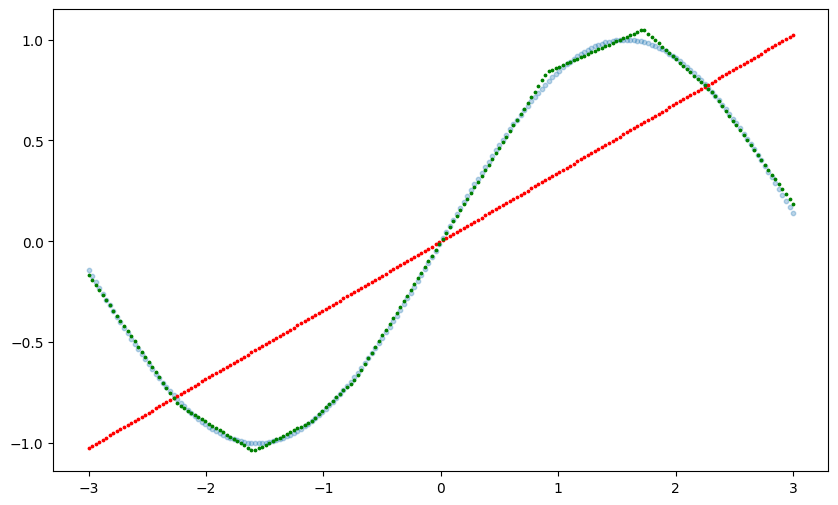

In [466]:
# 시각화
plt.figure(figsize = (10, 6))
# 원본 데이터
plt.scatter(x, y, s = 10, alpha = 0.3, label = "Origin Data")
# 선형모델 
plt.scatter(x, linear_pred, s = 3, c = 'red', label = 'Linear Model')
plt.scatter(x, relu_pred, s = 3, c = 'green')
plt.show()